In [65]:
import pandas as pd

csv_path = r'H:\HTOC\notebooks\Gap Observation 2.0\Splunk_TC_Address_Index.csv'
results_df = pd.read_csv(csv_path)

# Display first few rows to check data
results_df

,id,dateAdded,ownerId,ownerName,webLink,type,lastModified,rating,confidence,threatAssessRating,...,active,activeLocked,ip,legacyLink,tags.data,associatedGroups.data,description,source,lastFalsePositive,indicator
0,5629499537015520,2025-04-23T15:01:06Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-06T13:19:09Z,5.0,47.0,5.00,...,True,False,103.216.220.35,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 471298, 'name': 'DHA Splunk API', 'las...","[{'id': 6755399444000513, 'dateAdded': '2025-0...",NaN,NaN,NaN,103.216.220.35
1,4905098,2024-09-20T14:31:23Z,42,CAL Automated Threat Library,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-06T13:17:51Z,0.0,0.0,2.00,...,True,False,103.20.222.218,https://hvs.threatconnect.com/auth/indicators/...,NaN,"[{'id': 464084, 'dateAdded': '2024-09-20T14:31...",NaN,NaN,NaN,103.20.222.218
2,448067,2017-12-22T17:31:12Z,6,HTOC Comm,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-06T12:52:21Z,2.0,NaN,2.68,...,True,False,103.254.16.168,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 2098, 'name': 'Grizzly_Steppe'}]","[{'id': 90803, 'dateAdded': '2019-12-17T17:38:...",This indicator was included in FBI/NCCIC JAR 1...,FBI/NCCIC JAR 16-20540,NaN,103.254.16.168
3,5629499588087383,2026-02-13T08:47:16Z,1009000,Google Threat Intelligence,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-06T12:43:52Z,5.0,81.0,2.78,...,True,False,103.226.132.7,https://hvs.threatconnect.com/auth/indicators/...,NaN,"[{'id': 5629499574000095, 'dateAdded': '2026-0...",This indicator is malicious (high severity) wi...,https://www.virustotal.com/gui/ip-address/103....,NaN,103.226.132.7
4,5629499572136493,2025-10-16T15:41:04Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-06T12:42:47Z,3.0,52.0,0.75,...,True,False,101.71.130.99,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 2076981, 'name': 'SOAR Indicator PB', ...",NaN,INC9270850,NaN,NaN,101.71.130.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4059,5629499587152913,2026-02-10T06:44:31Z,1009000,Google Threat Intelligence,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-01T07:08:16Z,4.0,85.0,3.00,...,True,False,95.216.13.196,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 1820247, 'name': 'malware', 'lastUsed'...","[{'id': 6755399481012261, 'dateAdded': '2026-0...",This indicator is malicious (medium severity)....,https://www.virustotal.com/gui/ip-address/95.2...,NaN,95.216.13.196
4060,6755399467472828,2025-08-14T13:50:55Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T07:06:20Z,5.0,31.0,2.50,...,True,False,96.67.212.83,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 1466317, 'name': 'FortiGate', 'lastUse...","[{'id': 5629499550023739, 'dateAdded': '2025-0...","On August 3, GreyNoise observed a significant ...",NaN,NaN,96.67.212.83
4061,6755399491292976,2026-02-10T10:42:53Z,1009000,Google Threat Intelligence,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T07:05:31Z,3.0,91.0,3.00,...,True,False,96.44.157.203,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 1820247, 'name': 'malware', 'lastUsed'...","[{'id': 6755399481010733, 'dateAdded': '2026-0...",This indicator is malicious (medium severity)....,https://www.virustotal.com/gui/ip-address/96.4...,NaN,96.44.157.203
4062,6755399447112767,2025-05-15T12:40:41Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T07:04:12Z,5.0,51.0,3.50,...,True,False,96.9.124.89,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 493475, 'name': 'CL-STA-0048', 'lastUs...","[{'id': 5629499540002138, 'dateAdded': '2025-0...",Executive Summary\n \n\nEclecticIQ analysts as...,NaN,NaN,96.9.124.89


## `results_df` behavioral analysis

This section profiles `results_df` and visualizes how values are distributed across indicator types, scoring fields, tags, and time-like columns.


import sys
import os
import urllib3
from configparser import ConfigParser

# Add your local ThreatConnect SDK to path
sys.path.append(r"Z:\HTOC\Data_Analytics\threatconnect")
from ThreatConnect import ThreatConnect
from RequestObject import RequestObject
from Owners import Owners

# Add your project repo to path
project_root = r"H:\HTOC\scripts\Data Movement\ThrearConnect-api-pull"
if project_root not in sys.path:
    sys.path.append(project_root)

from utils.config_loader import load_config

# Load API config
config_path = os.path.join(project_root, "utils", "config.json")
try:
    api_secret_key, api_access_id, api_base_url, api_default_org = load_config(config_path)
    display(f"Loaded config from: {config_path}")
    display(f"Base URL: {api_base_url}")
    display(f"Access ID: {api_access_id}")
    display(f"Default Org: {api_default_org}")
except Exception as e:
    display(f"[ERROR] Failed to load configuration: {e}")
    sys.exit(1)

# Disable SSL verification warnings (use cautiously)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
verify_ssl = False

# Initialize ThreatConnect session
try:
    tc = ThreatConnect(api_access_id, api_secret_key, api_default_org, api_base_url)
    display("ThreatConnect initialized.")
except Exception as e:
    display(f"[ERROR] Failed to initialize ThreatConnect: {e}")
    sys.exit(1)

owner = 'HTOC Org'

try:
    ro = RequestObject()
    ro.set_http_method('GET')
    ro.set_owner(owner)
    ro.set_owner_allowed(True)
    display("RequestObject successfully created.")
except Exception as e:
    display(f"[ERROR] Failed to initialize RequestObject: {e}")
    sys.exit(1)


import urllib.parse
import pandas as pd

splunk_indicators = sorted(set(df["indicator"].astype(str).str.strip().str.split().str[0]))
print(f"Indicators to query: {len(splunk_indicators):,}")

FIELDS = "tags,observations,associatedGroups,falsePositives,threatAssess"
BATCH = 100
retrieved_items = []

for i in range(0, len(splunk_indicators), BATCH):
    chunk = splunk_indicators[i:i + BATCH]
    quoted = ",".join(f'"{s}"' for s in chunk)
    tql = urllib.parse.quote(f'summary in ({quoted})', safe="")

    ro = RequestObject()
    ro.set_http_method("GET")
    ro.set_request_uri(f"/v3/indicators?tql={tql}&fields={FIELDS}&resultLimit=10000")

    try:
        resp = tc.api_request(ro)
        if resp.headers.get("content-type", "").startswith("application/json"):
            data = (resp.json() or {}).get("data") or []
            retrieved_items.extend(d for d in data if isinstance(d, dict))
    except Exception as e:
        print(f"Batch {i} failed: {e}")

    if (i // BATCH) % 5 == 0:
        print(f"Processed {min(i + BATCH, len(splunk_indicators)):,}/{len(splunk_indicators):,}")

if retrieved_items:
    results_df = pd.json_normalize(retrieved_items)
    if "summary" in results_df.columns:
        results_df["indicator"] = results_df["summary"].astype(str).str.split().str[0].str.strip()
    results_df = results_df.drop_duplicates(subset=["indicator"]).reset_index(drop=True)
else:
    results_df = pd.DataFrame()

found = set(results_df["indicator"]) if not results_df.empty else set()
not_found = [s for s in splunk_indicators if s not in found]
print(f"Retrieved: {len(results_df):,} | Not found: {len(not_found):,}")


## What the library records about these indicators

For every indicator Splunk saw, we pulled four fields from the threat library:

1. **Score (1-5)** — the library's `rating` value for the indicator.
2. **Confidence (0-100)** — the library's confidence value.
3. **ThreatAssess rating (0-5)** — the library's combined assessment number.
4. **Tags** — labels attached to each indicator.

The charts below show how each field is distributed across the indicators.

Looking at 4,064 indicators.



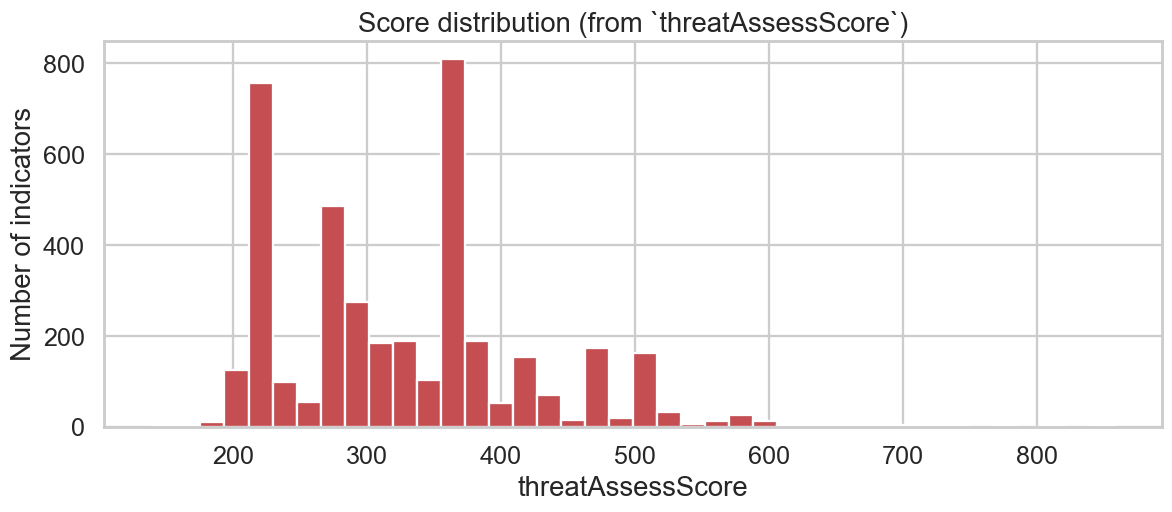

    → What this chart shows: every indicator gets a 'score' from the library. A small score means the library doesn't think it's much of a problem. A big score means the library thinks it might be a problem. Tall bars = lots of indicators got that score.

`threatAssessScore` range: 140 to 857. Average: 330.71. Median: 326.00. Indicators with no value: 0.



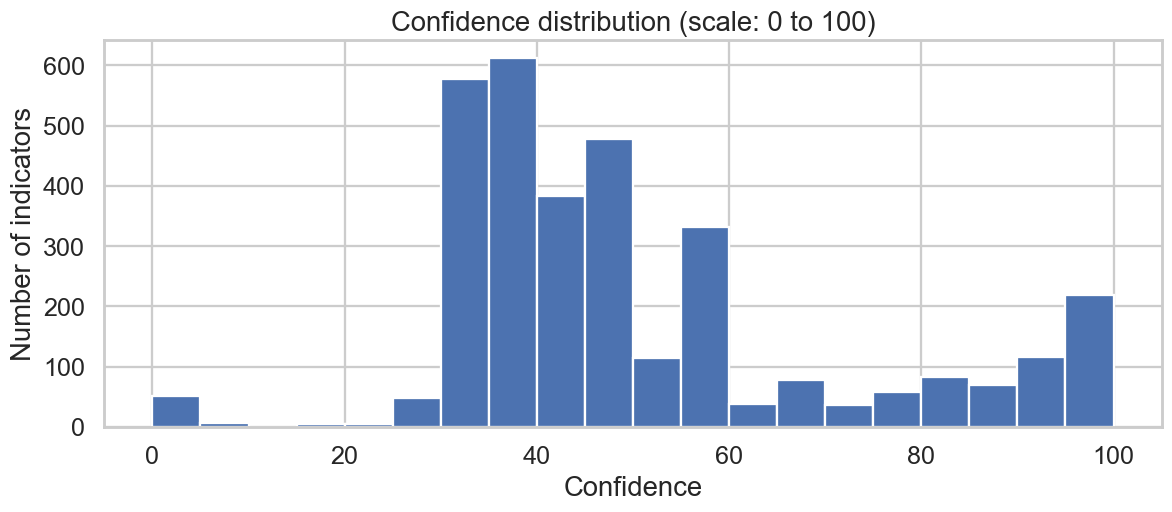

    → What this chart shows: confidence is how SURE the library is about the score it gave. 0 means it's just guessing, 100 means it's very sure. Tall bars = lots of indicators sit at that confidence level.

Average confidence: 50.1. Median: 44.0. Confidence ≥ 70: 581. Confidence < 40: 1,303.



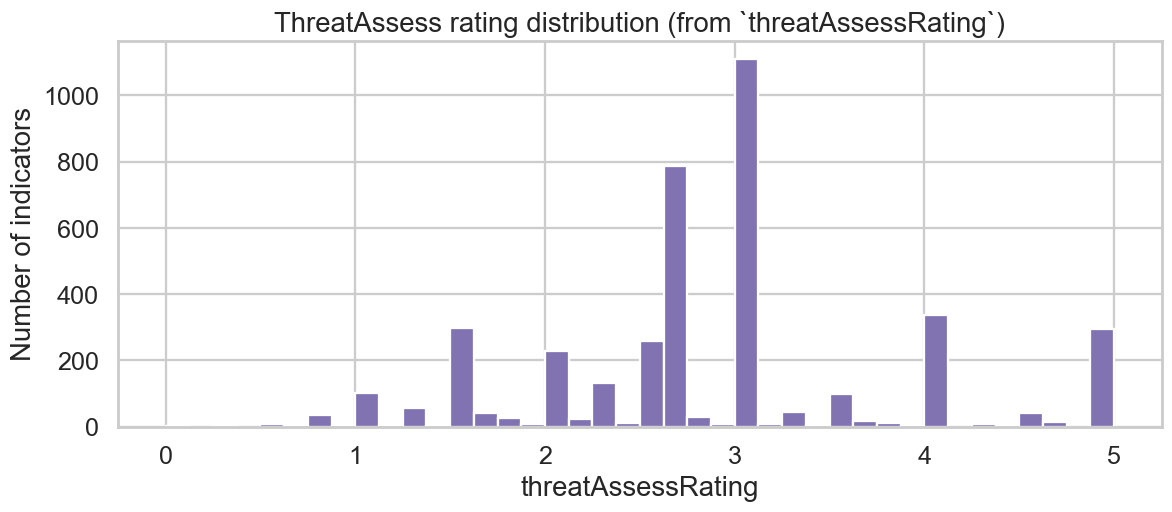

    → What this chart shows: this is another kind of score, but on a smaller 0-to-5 scale. Each indicator gets one number. Tall bars = lots of indicators landed on that number.

Average: 2.86. Median: 2.74. Three most common values: 3.0 (1,089 indicators), 2.68 (708 indicators), 4.0 (338 indicators).



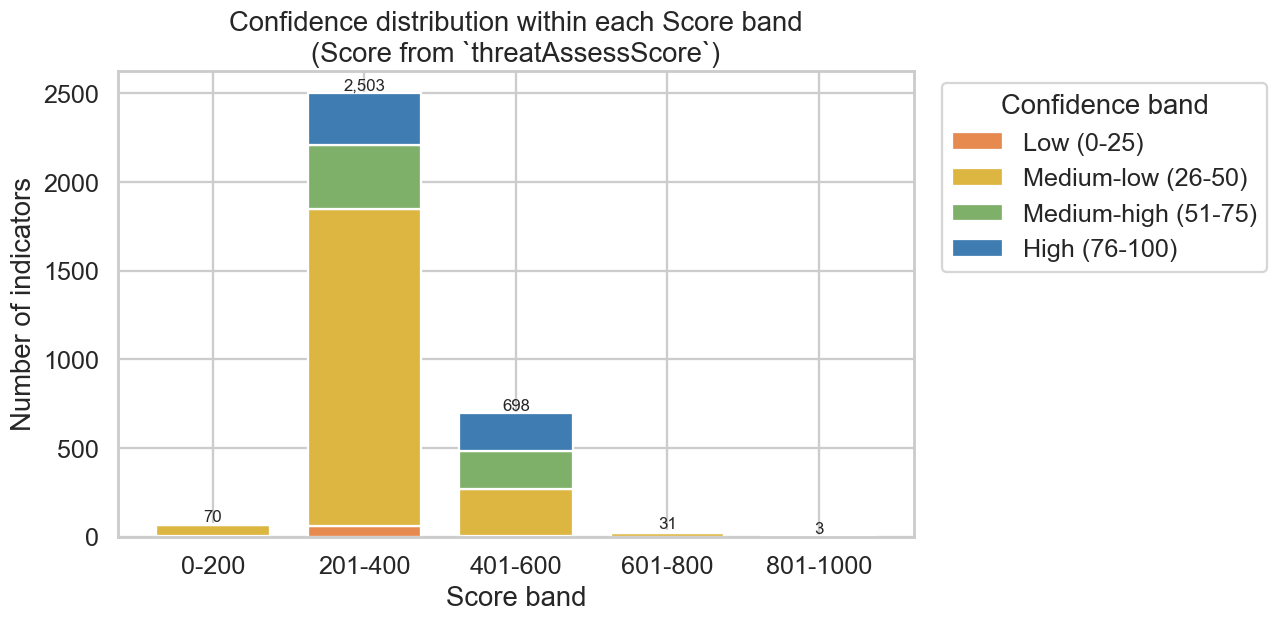

    → What this chart shows: every tall column is a group of indicators with similar scores. The colors inside each column tell you how SURE the library is. Blue at the top = the library is very sure. Orange at the bottom = it's basically guessing.

Score in top band (801-1000) AND Confidence ≥ 70: 1. Score in top band AND Confidence < 40: 0. Score in bottom band (0-200) AND Confidence ≥ 70: 0.



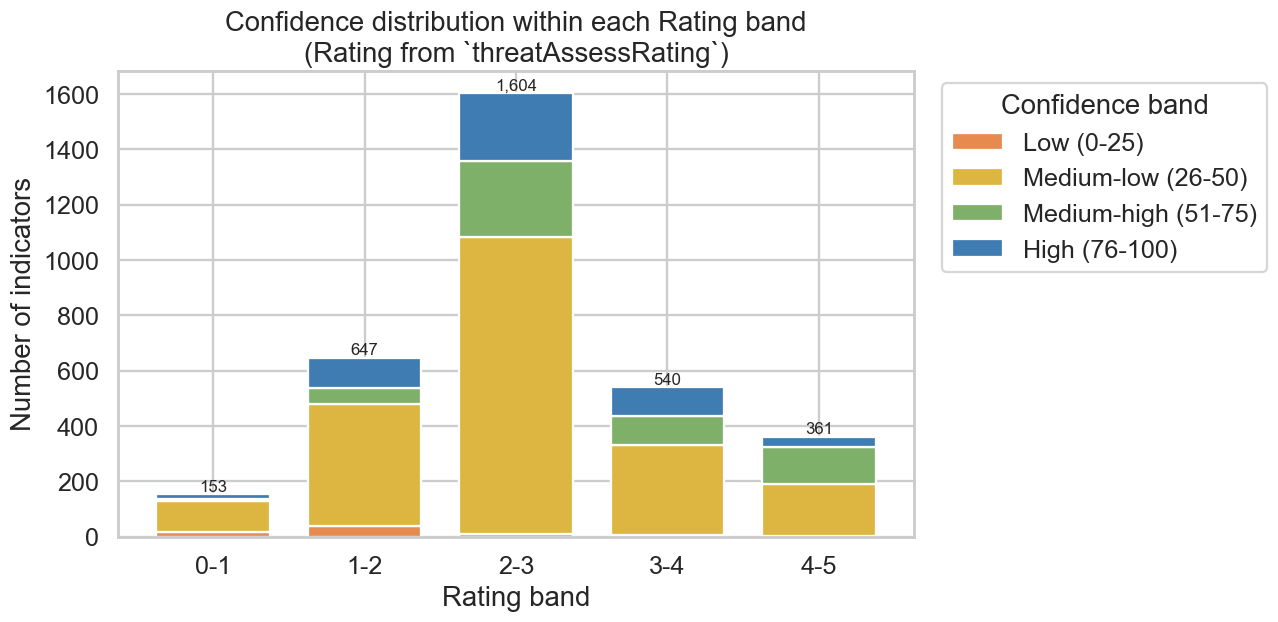

    → What this chart shows: same idea as the chart above, but using the rating instead of the score. Each column is a rating group. Colors inside show how sure the library is for that group.

Rating ≥ 4 AND Confidence ≥ 70: 116. Rating ≥ 4 AND Confidence < 40: 278. Rating ≤ 2 AND Confidence ≥ 70: 129.



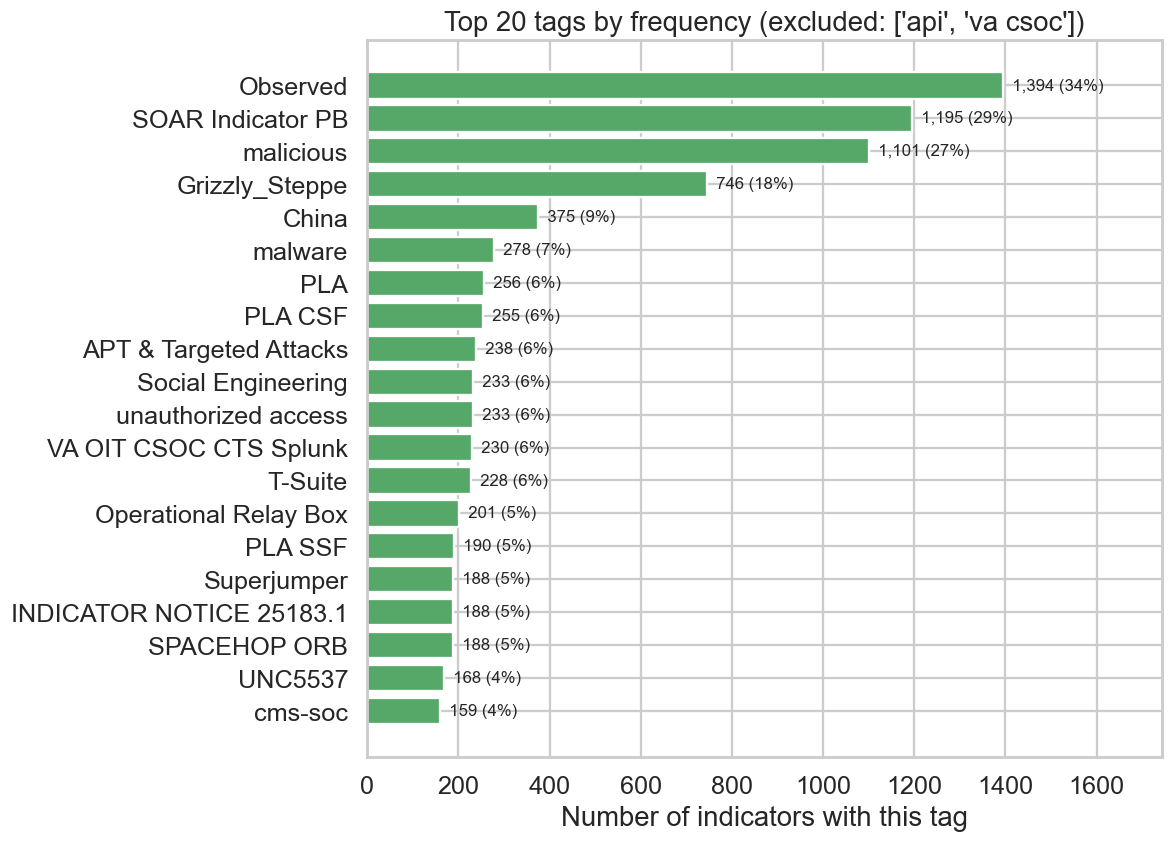

    → What this chart shows: tags are labels stuck onto each indicator (like 'malicious' or 'China'). The longest bar is the label used the most. We hid tags that mention 'api' or 'va csoc' because they don't tell us much.

Unique tags in use: 991. Most common tag: 'Observed' (1,394 indicators). Average tags per indicator: 4.7. Indicators with 0 tags: 381 (9%).



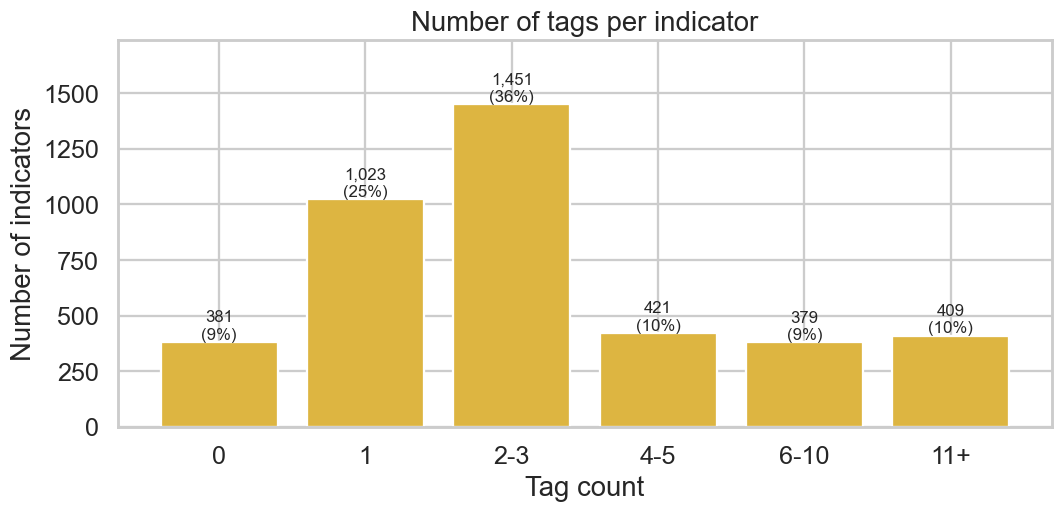

    → What this chart shows: how MANY labels each indicator has. 0 means it has no labels at all. 11+ means it has eleven or more labels piled on it.

Median tag count per indicator: 3. Maximum tag count on a single indicator: 165.



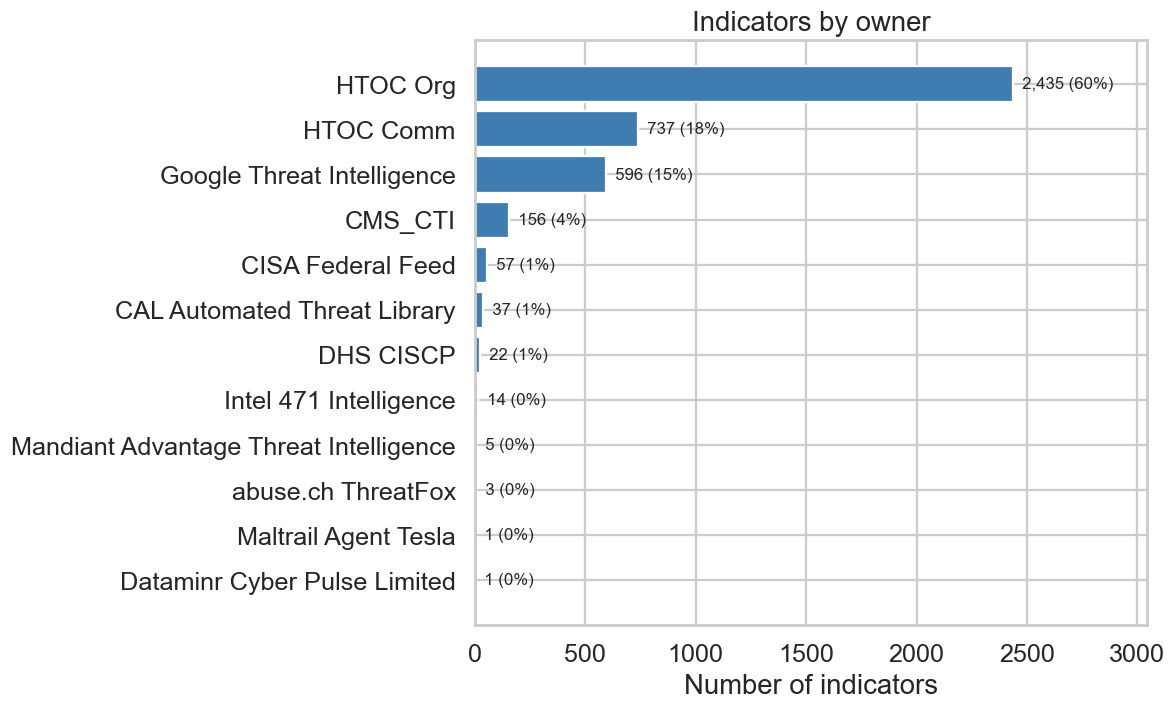

    → What this chart shows: every indicator belongs to a 'team' or owner inside the library. The longest bar is the team that has the most indicators.

Distinct owners: 12. Top owner: 'HTOC Org' (2,435 indicators, 60%). Indicators with no owner: 0.



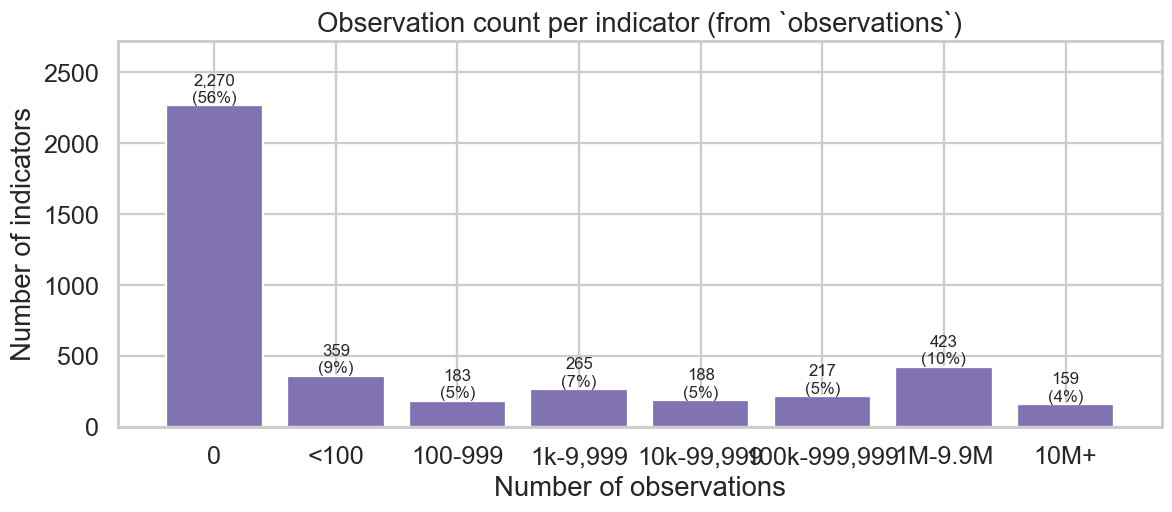

    → What this chart shows: every time something happens to an indicator, the library counts it as an 'observation'. 0 means nothing has ever been recorded for it. 10M+ means more than ten million observations on a single indicator.

Total observations: 9,525,379,833. Average: 2343843.5. Median: 0. Max: 404,437,003. Indicators with 0 observations: 2,270.

    → lastObserved buckets computed (No record, ≤30, 31-90, 91-365, >1 year).



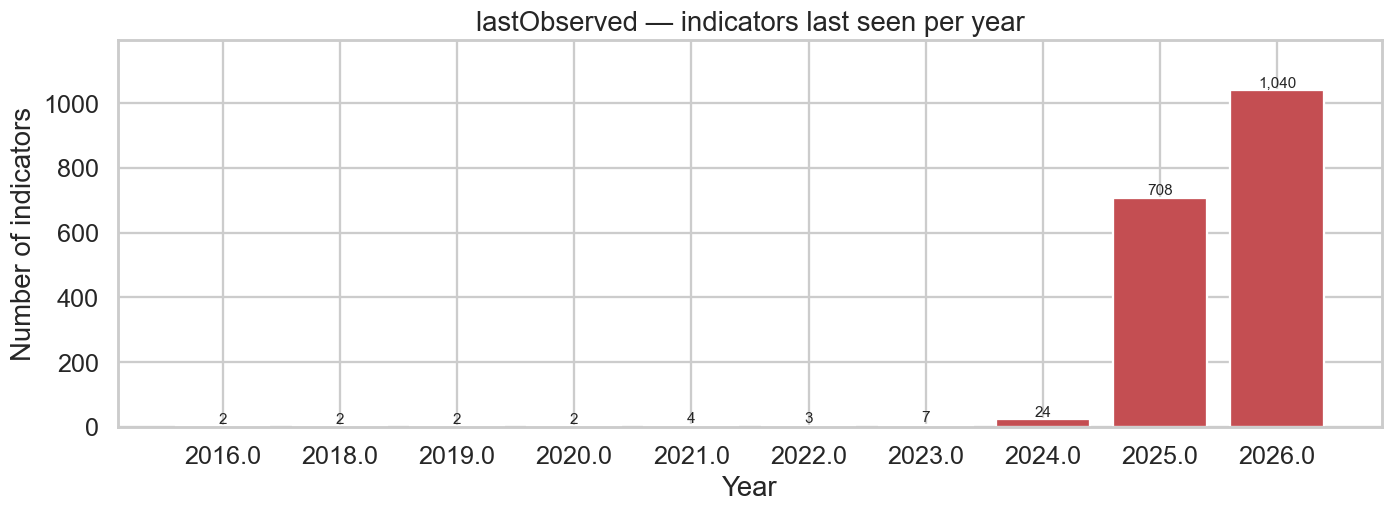

    → What this chart shows: in which year was each indicator last seen? Tall bar = lots of indicators were last seen in that year.

    → Monthly lastObserved chart removed.

Indicators with a lastObserved value: 1,794 (44%). No record: 2,270. Median age (days): 71. Oldest lastObserved: 2016-09-29. Newest: 2026-05-06.



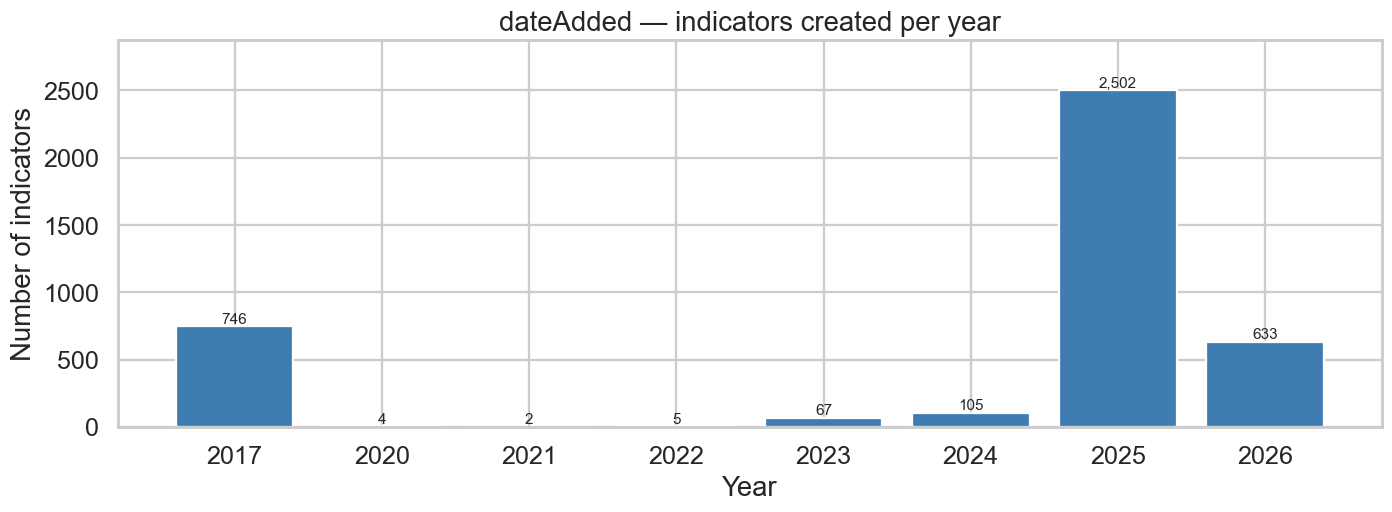

    → What this chart shows: in which year was each indicator added to the library? Tall bar = lots of indicators were added that year.

    → Monthly dateAdded chart removed.

dateAdded values present: 4,064 (100%). Oldest: 2017-01-03. Newest: 2026-05-04. Average age (days): 811. Year with most additions: 2025 (2,502).

SUMMARY
- Total indicators analyzed: 4,064
- Average threatAssessScore:   330.71
- Average confidence:            50.1
- Confidence ≥ 70 count:         581
- Average threatAssessRating:   2.86
- Average tags per indicator:    4.7
- Indicators with 0 tags:        381
- Excluded tags:                 ['api', 'va csoc']
- Distinct owners:               12
- Total observations:            9,525,379,833
- Indicators with lastObserved:  1,794
- dateAdded range:               2017-01-03 → 2026-05-04


In [66]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

assert "results_df" in globals() and not results_df.empty, "Run the lookup cell first."
data = results_df.copy()
total = len(data)
today = pd.Timestamp.utcnow()

def explain(text):
    """Print a plain-English explanation under each chart."""
    print("    → " + text)
    print()

print(f"Looking at {total:,} indicators.\n")

SCORE_FIELD = "threatAssessScore"
RATING_FIELD = "threatAssessRating"
EXCLUDED_TAG_SUBSTRINGS = ["api", "va csoc"]  # case-insensitive substring match

CONF_BAND_LABELS = ["Low (0-25)", "Medium-low (26-50)", "Medium-high (51-75)", "High (76-100)"]
CONF_BAND_BINS = [-1, 25, 50, 75, 100]
CONF_BAND_COLORS = ["#E68A4F", "#DDB541", "#7FB069", "#3E7CB1"]

def confidence_band(series):
    return pd.cut(series, bins=CONF_BAND_BINS, labels=CONF_BAND_LABELS)

# ===============================================================
# CHART 1 — Score distribution (threatAssessScore)
# ===============================================================
if SCORE_FIELD in data.columns:
    score = pd.to_numeric(data[SCORE_FIELD], errors="coerce").dropna()
    plt.figure(figsize=(11, 5))
    plt.hist(score, bins=40, color="#C44E52", edgecolor="white")
    plt.title(f"Score distribution (from `{SCORE_FIELD}`)")
    plt.xlabel(SCORE_FIELD); plt.ylabel("Number of indicators")
    plt.tight_layout(); plt.show()
    explain("What this chart shows: every indicator gets a 'score' from the library. A small score means the library doesn't think it's much of a problem. A big score means the library thinks it might be a problem. Tall bars = lots of indicators got that score.")
    print(f"`{SCORE_FIELD}` range: {score.min():g} to {score.max():g}. "
          f"Average: {score.mean():.2f}. Median: {score.median():.2f}. "
          f"Indicators with no value: {data[SCORE_FIELD].isna().sum():,}.\n")

# ===============================================================
# CHART 2 — Confidence distribution
# ===============================================================
if "confidence" in data.columns:
    conf = data["confidence"].dropna()
    plt.figure(figsize=(11, 5))
    plt.hist(conf, bins=20, color="#4C72B0", edgecolor="white")
    plt.title("Confidence distribution (scale: 0 to 100)")
    plt.xlabel("Confidence"); plt.ylabel("Number of indicators")
    plt.tight_layout(); plt.show()
    explain("What this chart shows: confidence is how SURE the library is about the score it gave. 0 means it's just guessing, 100 means it's very sure. Tall bars = lots of indicators sit at that confidence level.")
    print(f"Average confidence: {conf.mean():.1f}. Median: {conf.median():.1f}. "
          f"Confidence ≥ 70: {(conf >= 70).sum():,}. "
          f"Confidence < 40: {(conf < 40).sum():,}.\n")

# ===============================================================
# CHART 3 — ThreatAssess rating distribution
# ===============================================================
if RATING_FIELD in data.columns:
    tar = data[RATING_FIELD].dropna()
    plt.figure(figsize=(11, 5))
    plt.hist(tar, bins=40, color="#8172B2", edgecolor="white")
    plt.title(f"ThreatAssess rating distribution (from `{RATING_FIELD}`)")
    plt.xlabel(RATING_FIELD); plt.ylabel("Number of indicators")
    plt.tight_layout(); plt.show()
    explain('What this chart shows: this is another kind of score, but on a smaller 0-to-5 scale. Each indicator gets one number. Tall bars = lots of indicators landed on that number.')
    top_three = tar.round(2).value_counts().head(3)
    print(f"Average: {tar.mean():.2f}. Median: {tar.median():.2f}. "
          f"Three most common values: " +
          ", ".join(f"{v} ({c:,} indicators)" for v, c in top_three.items()) + ".\n")

# ===============================================================
# CHART 4 — Score × Confidence (stacked bar)
# ===============================================================
if SCORE_FIELD in data.columns and "confidence" in data.columns:
    sub = data.dropna(subset=[SCORE_FIELD, "confidence"]).copy()
    sub[SCORE_FIELD] = pd.to_numeric(sub[SCORE_FIELD], errors="coerce")
    sub = sub.dropna(subset=[SCORE_FIELD])

    s_max = sub[SCORE_FIELD].max()
    if s_max <= 5:
        bins = [-0.01, 1, 2, 3, 4, 5]
        labels = ["0-1", "1-2", "2-3", "3-4", "4-5"]
    elif s_max <= 100:
        bins = [-1, 20, 40, 60, 80, 100]
        labels = ["0-20", "21-40", "41-60", "61-80", "81-100"]
    else:
        bins = [-1, 200, 400, 600, 800, 1000]
        labels = ["0-200", "201-400", "401-600", "601-800", "801-1000"]

    sub["score_band"] = pd.cut(sub[SCORE_FIELD], bins=bins, labels=labels)
    sub["conf_band"] = confidence_band(sub["confidence"])

    grid = (sub.groupby(["score_band", "conf_band"], observed=True).size()
            .unstack(fill_value=0).sort_index())
    ax = grid.plot(kind="bar", stacked=True, figsize=(12, 6),
                   color=CONF_BAND_COLORS, edgecolor="white", width=0.75)
    ax.set_title(f"Confidence distribution within each Score band\n(Score from `{SCORE_FIELD}`)")
    ax.set_xlabel("Score band"); ax.set_ylabel("Number of indicators")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Confidence band", bbox_to_anchor=(1.02, 1), loc="upper left")
    for i, total_v in enumerate(grid.sum(axis=1)):
        ax.text(i, total_v, f"{total_v:,}", ha="center", va="bottom", fontsize=11)
    plt.tight_layout(); plt.show()
    explain("What this chart shows: every tall column is a group of indicators with similar scores. The colors inside each column tell you how SURE the library is. Blue at the top = the library is very sure. Orange at the bottom = it's basically guessing.")

    top_band, bot_band = labels[-1], labels[0]
    a = sub[(sub["score_band"] == top_band) & (sub["confidence"] >= 70)].shape[0]
    b = sub[(sub["score_band"] == top_band) & (sub["confidence"] < 40)].shape[0]
    c = sub[(sub["score_band"] == bot_band) & (sub["confidence"] >= 70)].shape[0]
    print(f"Score in top band ({top_band}) AND Confidence ≥ 70: {a:,}. "
          f"Score in top band AND Confidence < 40: {b:,}. "
          f"Score in bottom band ({bot_band}) AND Confidence ≥ 70: {c:,}.\n")

# ===============================================================
# CHART 4b — Rating × Confidence (stacked bar)
# ===============================================================
if RATING_FIELD in data.columns and "confidence" in data.columns:
    sub = data.dropna(subset=[RATING_FIELD, "confidence"]).copy()
    sub[RATING_FIELD] = pd.to_numeric(sub[RATING_FIELD], errors="coerce")
    sub = sub.dropna(subset=[RATING_FIELD])

    sub["rating_band"] = pd.cut(
        sub[RATING_FIELD],
        bins=[-0.01, 1, 2, 3, 4, 5],
        labels=["0-1", "1-2", "2-3", "3-4", "4-5"],
    )
    sub["conf_band"] = confidence_band(sub["confidence"])

    grid = (sub.groupby(["rating_band", "conf_band"], observed=True).size()
            .unstack(fill_value=0).sort_index())
    ax = grid.plot(kind="bar", stacked=True, figsize=(12, 6),
                   color=CONF_BAND_COLORS, edgecolor="white", width=0.75)
    ax.set_title(f"Confidence distribution within each Rating band\n(Rating from `{RATING_FIELD}`)")
    ax.set_xlabel("Rating band"); ax.set_ylabel("Number of indicators")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Confidence band", bbox_to_anchor=(1.02, 1), loc="upper left")
    for i, total_v in enumerate(grid.sum(axis=1)):
        ax.text(i, total_v, f"{total_v:,}", ha="center", va="bottom", fontsize=11)
    plt.tight_layout(); plt.show()
    explain('What this chart shows: same idea as the chart above, but using the rating instead of the score. Each column is a rating group. Colors inside show how sure the library is for that group.')

    a = sub[(sub[RATING_FIELD] >= 4) & (sub["confidence"] >= 70)].shape[0]
    b = sub[(sub[RATING_FIELD] >= 4) & (sub["confidence"] < 40)].shape[0]
    c = sub[(sub[RATING_FIELD] <= 2) & (sub["confidence"] >= 70)].shape[0]
    print(f"Rating ≥ 4 AND Confidence ≥ 70: {a:,}. "
          f"Rating ≥ 4 AND Confidence < 40: {b:,}. "
          f"Rating ≤ 2 AND Confidence ≥ 70: {c:,}.\n")

# ===============================================================
# CHART 5/6 — Tags (excluding 'API')
# ===============================================================
def extract_list_field(cell):
    if cell is None: return []
    if isinstance(cell, str):
        s = cell.strip()
        if not s or s.lower() == "nan": return []
        try: cell = ast.literal_eval(s)
        except (ValueError, SyntaxError): return []
    if isinstance(cell, dict): cell = [cell]
    if isinstance(cell, list): return cell
    return []

def extract_tag_names(cell):
    items = extract_list_field(cell)
    names = []
    for t in items:
        if isinstance(t, dict):
            n = t.get("name")
            if n:
                name = str(n).strip()
                lower = name.lower()
                if not any(ex in lower for ex in EXCLUDED_TAG_SUBSTRINGS):
                    names.append(name)
        elif isinstance(t, str) and t.strip():
            name = t.strip()
            lower = name.lower()
            if not any(ex in lower for ex in EXCLUDED_TAG_SUBSTRINGS):
                names.append(name)
    return names

if "tags.data" in data.columns:
    data["tag_names"] = data["tags.data"].apply(extract_tag_names)
    data["tag_count"] = data["tag_names"].str.len()
    all_tags = data["tag_names"].explode().dropna()
    all_tags = all_tags[all_tags.astype(str).str.len() > 0]
    if all_tags.empty:
        print("No tags found in 'tags.data' (after exclusions) — skipping tag charts.\n")
    else:
        top_tags = all_tags.value_counts().head(20)
        plt.figure(figsize=(11, 8))
        bars = plt.barh(top_tags.index[::-1], top_tags.values[::-1], color="#55A868")
        for bar, v in zip(bars, top_tags.values[::-1]):
            plt.text(v, bar.get_y() + bar.get_height()/2,
                     f"  {v:,} ({v/total*100:.0f}%)", va="center", fontsize=11)
        plt.title(f"Top 20 tags by frequency (excluded: {EXCLUDED_TAG_SUBSTRINGS})")
        plt.xlabel("Number of indicators with this tag")
        plt.xlim(0, top_tags.max() * 1.25); plt.tight_layout(); plt.show()
        explain("What this chart shows: tags are labels stuck onto each indicator (like 'malicious' or 'China'). The longest bar is the label used the most. We hid tags that mention 'api' or 'va csoc' because they don't tell us much.")
        unique_tags = all_tags.nunique()
        untagged = (data["tag_count"] == 0).sum()
        print(f"Unique tags in use: {unique_tags:,}. "
              f"Most common tag: '{top_tags.index[0]}' ({top_tags.iloc[0]:,} indicators). "
              f"Average tags per indicator: {data['tag_count'].mean():.1f}. "
              f"Indicators with 0 tags: {untagged:,} ({untagged/total*100:.0f}%).\n")

if "tag_count" in data.columns and data["tag_count"].sum() > 0:
    tag_buckets = pd.cut(
        data["tag_count"], bins=[-1, 0, 1, 3, 5, 10, 1000],
        labels=["0", "1", "2-3", "4-5", "6-10", "11+"],
    ).value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    bars = plt.bar(tag_buckets.index.astype(str), tag_buckets.values, color="#DDB541")
    for bar, v in zip(bars, tag_buckets.values):
        plt.text(bar.get_x() + bar.get_width()/2, v,
                 f"{v:,}\n({v/total*100:.0f}%)", ha="center", va="bottom", fontsize=11)
    plt.title("Number of tags per indicator")
    plt.xlabel("Tag count"); plt.ylabel("Number of indicators")
    plt.ylim(0, tag_buckets.max() * 1.2); plt.tight_layout(); plt.show()
    explain('What this chart shows: how MANY labels each indicator has. 0 means it has no labels at all. 11+ means it has eleven or more labels piled on it.')
    print(f"Median tag count per indicator: {data['tag_count'].median():.0f}. "
          f"Maximum tag count on a single indicator: {data['tag_count'].max()}.\n")

# ===============================================================
# CHART 7 — Owner name
# ===============================================================
if "ownerName" in data.columns:
    owner_counts = data["ownerName"].fillna("(missing)").value_counts()
    plt.figure(figsize=(11, max(4, 0.4 * len(owner_counts) + 2)))
    bars = plt.barh(owner_counts.index[::-1], owner_counts.values[::-1], color="#3E7CB1")
    for bar, v in zip(bars, owner_counts.values[::-1]):
        plt.text(v, bar.get_y() + bar.get_height()/2,
                 f"  {v:,} ({v/total*100:.0f}%)", va="center", fontsize=11)
    plt.title("Indicators by owner")
    plt.xlabel("Number of indicators")
    plt.xlim(0, owner_counts.max() * 1.25); plt.tight_layout(); plt.show()
    explain("What this chart shows: every indicator belongs to a 'team' or owner inside the library. The longest bar is the team that has the most indicators.")
    print(f"Distinct owners: {data['ownerName'].nunique(dropna=False)}. "
          f"Top owner: '{owner_counts.index[0]}' ({owner_counts.iloc[0]:,} indicators, "
          f"{owner_counts.iloc[0]/total*100:.0f}%). "
          f"Indicators with no owner: {data['ownerName'].isna().sum():,}.\n")

# ===============================================================
# CHART 8 — Observation count
# ===============================================================
obs_count_col = None
for cand in ["observationCount", "observations.count", "observations"]:
    if cand in data.columns and pd.api.types.is_numeric_dtype(data[cand]):
        obs_count_col = cand; break
if obs_count_col is None and "observations.data" in data.columns:
    data["observation_count"] = data["observations.data"].apply(lambda c: len(extract_list_field(c)))
    obs_count_col = "observation_count"

if obs_count_col is not None:
    oc = pd.to_numeric(data[obs_count_col], errors="coerce").fillna(0).astype(int)
    obs_buckets = pd.cut(oc, bins=[-1, 0, 99, 999, 9_999, 99_999, 999_999, 9_999_999, 1_000_000_000],
                         labels=["0", "1-99", "100-999", "1K-9.9K", "10K-99K", "100K-999K", "1M-9.9M", "10M+"]
                         ).value_counts().sort_index()
    plt.figure(figsize=(11, 5))
    bars = plt.bar(obs_buckets.index.astype(str), obs_buckets.values, color="#8172B2")
    for bar, v in zip(bars, obs_buckets.values):
        plt.text(bar.get_x() + bar.get_width()/2, v,
                 f"{v:,}\n({v/total*100:.0f}%)", ha="center", va="bottom", fontsize=11)
    plt.title(f"Observation count per indicator (from `{obs_count_col}`)")
    plt.xlabel("Number of observations"); plt.ylabel("Number of indicators")
    plt.ylim(0, obs_buckets.max() * 1.2); plt.tight_layout(); plt.show()
    explain("What this chart shows: every time something happens to an indicator, the library counts it as an 'observation'. 0 means nothing has ever been recorded for it. 10M+ means more than ten million observations on a single indicator.")
    print(f"Total observations: {oc.sum():,}. Average: {oc.mean():.1f}. "
          f"Median: {oc.median():.0f}. Max: {oc.max():,}. "
          f"Indicators with 0 observations: {(oc == 0).sum():,}.\n")
else:
    print("No observation count column found — skipping observation chart.\n")

# ===============================================================
# CHART 9 — lastObserved
# ===============================================================
if "lastObserved" in data.columns:
    last_obs = pd.to_datetime(data["lastObserved"], errors="coerce", utc=True)
    days_old = (today - last_obs).dt.days
    buckets = pd.Series({
        "No record":   last_obs.isna().sum(),
        "≤ 30 days":   ((days_old <= 30)).sum(),
        "31-90 days":  ((days_old > 30) & (days_old <= 90)).sum(),
        "91-365 days": ((days_old > 90) & (days_old <= 365)).sum(),
        "> 1 year":    ((days_old > 365)).sum(),
    })
    explain("lastObserved buckets computed (No record, ≤30, 31-90, 91-365, >1 year).")

    year_counts_lo = last_obs.dt.year.value_counts(dropna=True).sort_index().astype(int)
    if not year_counts_lo.empty:
        plt.figure(figsize=(13, 5))
        bars = plt.bar(year_counts_lo.index.astype(str), year_counts_lo.values, color="#C44E52")
        for bar, v in zip(bars, year_counts_lo.values):
            plt.text(bar.get_x() + bar.get_width()/2, v,
                     f"{v:,}", ha="center", va="bottom", fontsize=10)
        plt.title("lastObserved — indicators last seen per year")
        plt.xlabel("Year"); plt.ylabel("Number of indicators")
        plt.ylim(0, year_counts_lo.max() * 1.15); plt.tight_layout(); plt.show()
    explain('What this chart shows: in which year was each indicator last seen? Tall bar = lots of indicators were last seen in that year.')

    explain('Monthly lastObserved chart removed.')

    have = last_obs.notna().sum()
    if last_obs.notna().any():
        print(f"Indicators with a lastObserved value: {have:,} ({have/total*100:.0f}%). "
              f"No record: {total - have:,}. "
              f"Median age (days): {days_old.median():.0f}. "
              f"Oldest lastObserved: {last_obs.min().date()}. "
              f"Newest: {last_obs.max().date()}.\n")
    else:
        print(f"All {total:,} indicators have no lastObserved value.\n")

# ===============================================================
# CHART 10 — dateAdded
# ===============================================================
if "dateAdded" in data.columns:
    da = pd.to_datetime(data["dateAdded"], errors="coerce", utc=True)
    da_age = (today - da).dt.days

    year_counts = da.dt.year.value_counts(dropna=True).sort_index().astype(int)
    plt.figure(figsize=(13, 5))
    bars = plt.bar(year_counts.index.astype(str), year_counts.values, color="#3E7CB1")
    for bar, v in zip(bars, year_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, v,
                 f"{v:,}", ha="center", va="bottom", fontsize=10)
    plt.title("dateAdded — indicators created per year")
    plt.xlabel("Year"); plt.ylabel("Number of indicators")
    plt.ylim(0, year_counts.max() * 1.15); plt.tight_layout(); plt.show()
    explain('What this chart shows: in which year was each indicator added to the library? Tall bar = lots of indicators were added that year.')

    explain('Monthly dateAdded chart removed.')

    if da.notna().any():
        print(f"dateAdded values present: {da.notna().sum():,} "
              f"({da.notna().mean()*100:.0f}%). "
              f"Oldest: {da.min().date()}. Newest: {da.max().date()}. "
              f"Average age (days): {da_age.mean():.0f}. "
              f"Year with most additions: {year_counts.idxmax()} ({year_counts.max():,}).\n")
    else:
        print("No valid dateAdded values found.\n")

# ===============================================================
# Summary
# ===============================================================
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"- Total indicators analyzed: {total:,}")
if SCORE_FIELD in data.columns:
    s = pd.to_numeric(data[SCORE_FIELD], errors="coerce")
    print(f"- Average {SCORE_FIELD}:   {s.mean():.2f}")
if "confidence" in data.columns:
    print(f"- Average confidence:            {data['confidence'].mean():.1f}")
    print(f"- Confidence ≥ 70 count:         {(data['confidence'] >= 70).sum():,}")
if RATING_FIELD in data.columns:
    print(f"- Average {RATING_FIELD}:   {data[RATING_FIELD].mean():.2f}")
if "tag_count" in data.columns:
    print(f"- Average tags per indicator:    {data['tag_count'].mean():.1f}")
    print(f"- Indicators with 0 tags:        {(data['tag_count'] == 0).sum():,}")
    print(f"- Excluded tags:                 {EXCLUDED_TAG_SUBSTRINGS}")
if "ownerName" in data.columns:
    print(f"- Distinct owners:               {data['ownerName'].nunique(dropna=False)}")
if obs_count_col is not None:
    oc_all = pd.to_numeric(data[obs_count_col], errors='coerce').fillna(0)
    print(f"- Total observations:            {oc_all.sum():,.0f}")
if "lastObserved" in data.columns:
    lo = pd.to_datetime(data["lastObserved"], errors="coerce", utc=True)
    print(f"- Indicators with lastObserved:  {lo.notna().sum():,}")
if "dateAdded" in data.columns:
    da = pd.to_datetime(data["dateAdded"], errors="coerce", utc=True)
    if da.notna().any():
        print(f"- dateAdded range:               {da.min().date()} → {da.max().date()}")

## Zero-observation indicators — what do they look like?

Roughly 56% of the indicators in this list have **0 observations**. 

The charts below split the indicators into two groups and compare them side-by-side:

- **Group A — has observations** (1 or more)
- **Group B — zero observations**

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

assert "results_df" in globals() and not results_df.empty, "Run the lookup cell first."

z = results_df.copy()

def explain(text):
    print("    -> " + text)
    print()

def _to_list(cell):
    if cell is None: return []
    if isinstance(cell, str):
        s = cell.strip()
        if not s or s.lower() == "nan": return []
        try: return ast.literal_eval(s)
        except (ValueError, SyntaxError): return []
    if isinstance(cell, list): return cell
    if isinstance(cell, dict): return [cell]
    return []

if "observationCount" in z.columns:
    z["obs_count"] = pd.to_numeric(z["observationCount"], errors="coerce").fillna(0).astype(int)
elif "observations.count" in z.columns:
    z["obs_count"] = pd.to_numeric(z["observations.count"], errors="coerce").fillna(0).astype(int)
elif "observations" in z.columns and pd.api.types.is_numeric_dtype(z["observations"]):
    z["obs_count"] = pd.to_numeric(z["observations"], errors="coerce").fillna(0).astype(int)
elif "observations.data" in z.columns:
    z["obs_count"] = z["observations.data"].apply(lambda c: len(_to_list(c)))
else:
    z["obs_count"] = 0
    print("Warning: No observation column found in results_df; defaulting obs_count to 0 for all rows.")

z["group"] = z["obs_count"].apply(lambda n: "Has observations" if n > 0 else "Zero observations")

g_zero = z[z["group"] == "Zero observations"]
g_has  = z[z["group"] == "Has observations"]
total = len(z)

print(f"Total indicators: {total:,}")
print(f"  Has observations:  {len(g_has):,} ({len(g_has)/total*100:.0f}%)")
print(f"  Zero observations: {len(g_zero):,} ({len(g_zero)/total*100:.0f}%)\n")

GROUP_COLORS = {"Has observations": "#3E7CB1", "Zero observations": "#C44E52"}

# ---------------- CHART A: group sizes ----------------
gc = z["group"].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(gc.index, gc.values, color=[GROUP_COLORS[i] for i in gc.index])
for bar, v in zip(bars, gc.values):
    plt.text(bar.get_x() + bar.get_width()/2, v,
             f"{v:,}\n({v/total*100:.0f}%)", ha="center", va="bottom", fontsize=12)
plt.title("How many indicators are in each group?")
plt.ylabel("Number of indicators")
plt.ylim(0, gc.max() * 1.2)
plt.tight_layout(); plt.show()
explain("How the indicators split between the two groups. The taller bar wins.")

# ---------------- CHART B: Score side-by-side ----------------
SCORE_FIELD = "threatAssessScore"
if SCORE_FIELD in z.columns:
    plt.figure(figsize=(11, 5))
    for grp, color in GROUP_COLORS.items():
        vals = pd.to_numeric(z.loc[z["group"] == grp, SCORE_FIELD], errors="coerce").dropna()
        if not vals.empty:
            plt.hist(vals, bins=40, alpha=0.55, label=f"{grp} (n={len(vals):,})",
                     color=color, edgecolor="white")
    plt.title(f"Score (`{SCORE_FIELD}`) - both groups overlaid")
    plt.xlabel("Score"); plt.ylabel("Number of indicators")
    plt.legend()
    plt.tight_layout(); plt.show()
    explain("Score for both groups, on the same chart. If the red and blue shapes overlap exactly, the two groups score the same. If one shape is shifted, the score is different.")

    s_has  = pd.to_numeric(g_has[SCORE_FIELD], errors="coerce")
    s_zero = pd.to_numeric(g_zero[SCORE_FIELD], errors="coerce")
    print(f"Average score - Has obs: {s_has.mean():.2f} | Zero obs: {s_zero.mean():.2f}")
    print(f"Median score  - Has obs: {s_has.median():.2f} | Zero obs: {s_zero.median():.2f}")
    score_bins = [-0.01, 0, 25, 50, 75, 100, float("inf")]
    score_labels = ["0", "1-25", "26-50", "51-75", "76-100", "100+"]
    score_pivot = (pd.DataFrame({
            "group": z["group"],
            "bucket": pd.cut(pd.to_numeric(z[SCORE_FIELD], errors="coerce"), bins=score_bins, labels=score_labels)
        })
        .dropna()
        .groupby(["bucket", "group"], observed=True).size()
        .unstack(fill_value=0))
    for col in GROUP_COLORS:
        if col not in score_pivot.columns:
            score_pivot[col] = 0
    score_pivot = score_pivot[list(GROUP_COLORS.keys())]
    print("Score counts by bucket and group:")
    print(score_pivot.to_string())
    print()

# ---------------- CHART C: Confidence side-by-side ----------------
if "confidence" in z.columns:
    plt.figure(figsize=(11, 5))
    for grp, color in GROUP_COLORS.items():
        vals = z.loc[z["group"] == grp, "confidence"].dropna()
        if not vals.empty:
            plt.hist(vals, bins=20, alpha=0.55, label=f"{grp} (n={len(vals):,})",
                     color=color, edgecolor="white")
    plt.title("Confidence - both groups overlaid")
    plt.xlabel("Confidence (0-100)"); plt.ylabel("Number of indicators")
    plt.legend()
    plt.tight_layout(); plt.show()
    explain("Confidence for both groups. If one shape leans left (low) and the other right (high), the library is more sure about one group than the other.")

    print(f"Average confidence - Has obs: {g_has['confidence'].mean():.1f} | Zero obs: {g_zero['confidence'].mean():.1f}")
    print(f"Median confidence  - Has obs: {g_has['confidence'].median():.1f} | Zero obs: {g_zero['confidence'].median():.1f}")
    conf_bins = [-0.01, 0, 25, 50, 75, 100]
    conf_labels = ["0", "1-25", "26-50", "51-75", "76-100"]
    conf_pivot = (pd.DataFrame({
            "group": z["group"],
            "bucket": pd.cut(pd.to_numeric(z["confidence"], errors="coerce"), bins=conf_bins, labels=conf_labels)
        })
        .dropna()
        .groupby(["bucket", "group"], observed=True).size()
        .unstack(fill_value=0))
    for col in GROUP_COLORS:
        if col not in conf_pivot.columns:
            conf_pivot[col] = 0
    conf_pivot = conf_pivot[list(GROUP_COLORS.keys())]
    print("Confidence counts by bucket and group:")
    print(conf_pivot.to_string())
    print()

# ---------------- CHART D: dateAdded by year, by group ----------------
if "dateAdded" in z.columns:
    da = pd.to_datetime(z["dateAdded"], errors="coerce", utc=True)
    z["year_added"] = da.dt.year

    pivot = (z.groupby(["year_added", "group"]).size()
              .unstack(fill_value=0).sort_index())
    for col in GROUP_COLORS:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot[list(GROUP_COLORS.keys())]

    ax = pivot.plot(kind="bar", figsize=(13, 5),
                    color=[GROUP_COLORS[c] for c in pivot.columns],
                    edgecolor="white", width=0.8)
    ax.set_title("When were the indicators added? (by group)")
    ax.set_xlabel("Year added"); ax.set_ylabel("Number of indicators")
    ax.set_xticklabels([int(y) for y in pivot.index], rotation=0)
    ax.legend(title="Group")
    for container in ax.containers:
        ax.bar_label(container,
                     labels=[f"{int(v):,}" if v > 0 else "" for v in container.datavalues],
                     fontsize=9, padding=2)
    ax.set_ylim(0, pivot.values.max() * 1.15)
    plt.tight_layout(); plt.show()
    explain("Each year split by group. If one color dominates a year, that year added mostly that kind of indicator.")
    print("Counts by year and group:")
    print(pivot.to_string())
    print()

# ---------------- CHART E: Tag count by group ----------------
EXCLUDED_TAG_SUBSTRINGS = ["api", "va csoc"]

def extract_tag_names(cell):
    items = _to_list(cell)
    out = []
    for t in items:
        if isinstance(t, dict):
            n = t.get("name")
            if n:
                name = str(n).strip()
                if not any(ex in name.lower() for ex in EXCLUDED_TAG_SUBSTRINGS):
                    out.append(name)
        elif isinstance(t, str) and t.strip():
            name = t.strip()
            if not any(ex in name.lower() for ex in EXCLUDED_TAG_SUBSTRINGS):
                out.append(name)
    return out

if "tags.data" in z.columns:
    z["tag_names"] = z["tags.data"].apply(extract_tag_names)
    z["tag_count"] = z["tag_names"].str.len()
    g_zero = z[z["group"] == "Zero observations"]
    g_has  = z[z["group"] == "Has observations"]

    bins = [-1, 0, 1, 3, 5, 10, 1000]
    labels = ["0", "1", "2-3", "4-5", "6-10", "11+"]
    z["tag_bucket"] = pd.cut(z["tag_count"], bins=bins, labels=labels)

    pivot = (z.groupby(["tag_bucket", "group"], observed=True).size()
              .unstack(fill_value=0))
    for col in GROUP_COLORS:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot[list(GROUP_COLORS.keys())]

    ax = pivot.plot(kind="bar", figsize=(11, 5),
                    color=[GROUP_COLORS[c] for c in pivot.columns],
                    edgecolor="white", width=0.8)
    ax.set_title("How many tags do indicators have? (by group)")
    ax.set_xlabel("Tag count"); ax.set_ylabel("Number of indicators")
    ax.set_xticklabels(labels, rotation=0)
    ax.legend(title="Group")
    for container in ax.containers:
        ax.bar_label(container,
                     labels=[f"{int(v):,}" if v > 0 else "" for v in container.datavalues],
                     fontsize=9, padding=2)
    ax.set_ylim(0, pivot.values.max() * 1.15)
    plt.tight_layout(); plt.show()
    explain("How many tags each indicator has, split by group. If the zero-observation group is heavy on the '0' bar, those indicators have nothing labeled on them at all.")

    print(f"Average tags per indicator - Has obs: {g_has['tag_count'].mean():.1f} | "
          f"Zero obs: {z.loc[z['group']=='Zero observations','tag_count'].mean():.1f}")
    print(f"Indicators with 0 tags     - Has obs: {(g_has['tag_count']==0).sum():,} | "
          f"Zero obs: {(z.loc[z['group']=='Zero observations','tag_count']==0).sum():,}")
    print("Tag-count counts by bucket and group:")
    print(pivot.to_string())
    print()

# ---------------- CHART F: Top tags within zero-obs group ----------------
if "tag_names" in z.columns:
    zero_tags = (z.loc[z["group"] == "Zero observations", "tag_names"]
                  .explode().dropna())
    zero_tags = zero_tags[zero_tags.astype(str).str.len() > 0]
    if not zero_tags.empty:
        top = zero_tags.value_counts().head(20)
        plt.figure(figsize=(11, 8))
        bars = plt.barh(top.index[::-1], top.values[::-1], color="#C44E52")
        for bar, v in zip(bars, top.values[::-1]):
            plt.text(v, bar.get_y() + bar.get_height()/2,
                     f"  {v:,} ({v/len(g_zero)*100:.0f}%)", va="center", fontsize=11)
        plt.title("Top 20 tags - among ZERO-observation indicators only")
        plt.xlabel("Number of zero-observation indicators with this tag")
        plt.xlim(0, top.max() * 1.25)
        plt.tight_layout(); plt.show()
        explain("Labels most often stuck on the zero-observation indicators. If one tag dominates here, it tells us where these 'never seen' indicators came from.")
    else:
        print("Zero-observation indicators have no tags at all.\n")

# ---------------- CHART G: Owner breakdown of zero-obs group ----------------
if "ownerName" in z.columns:
    counts = (z[z["group"] == "Zero observations"]["ownerName"]
              .fillna("(missing)").value_counts())
    if not counts.empty:
        plt.figure(figsize=(11, max(4, 0.4 * len(counts) + 2)))
        bars = plt.barh(counts.index[::-1], counts.values[::-1], color="#C44E52")
        for bar, v in zip(bars, counts.values[::-1]):
            plt.text(v, bar.get_y() + bar.get_height()/2,
                     f"  {v:,} ({v/len(g_zero)*100:.0f}%)", va="center", fontsize=11)
        plt.title("Who owns the zero-observation indicators?")
        plt.xlabel("Number of zero-observation indicators")
        plt.xlim(0, counts.max() * 1.25)
        plt.tight_layout(); plt.show()
        explain("Which owner team is responsible for the zero-observation indicators. If one team owns most of them, that team's feed may not be reporting observations back.")

# ---------------- Summary ----------------
print("=" * 60)
print("ZERO-OBSERVATION SUMMARY")
print("=" * 60)
print(f"- Zero-observation indicators: {len(g_zero):,} ({len(g_zero)/total*100:.0f}%)")
if SCORE_FIELD in z.columns:
    sz = pd.to_numeric(g_zero[SCORE_FIELD], errors="coerce")
    sh = pd.to_numeric(g_has[SCORE_FIELD], errors="coerce")
    print(f"- Avg score:      {sz.mean():.2f} (zero) vs {sh.mean():.2f} (has obs)")
if "confidence" in z.columns:
    print(f"- Avg confidence: {g_zero['confidence'].mean():.1f} (zero) vs {g_has['confidence'].mean():.1f} (has obs)")
if "tag_count" in z.columns:
    print(f"- Avg tags:       {g_zero['tag_count'].mean():.1f} (zero) vs {g_has['tag_count'].mean():.1f} (has obs)")
    print(f"- Untagged:       {(g_zero['tag_count']==0).sum():,} (zero) vs {(g_has['tag_count']==0).sum():,} (has obs)")
if "ownerName" in z.columns:
    top_owner = g_zero["ownerName"].fillna("(missing)").value_counts().idxmax()
    top_owner_n = g_zero["ownerName"].fillna("(missing)").value_counts().max()
    print(f"- Top owner of zero-obs: {top_owner} ({top_owner_n:,})")

## 2017 indicators — what do they look like?

A big chunk of the indicators (746 of them) were added in 2017 — most of them in a single bulk-load near the end of that year. After that, almost nothing was added until 2023.

The charts below split the indicators into two groups and compare them side-by-side:

- **Group A — added in 2017**
- **Group B — added after 2017**

If the two groups look similar, the 2017 cohort is just old but normal. If they look different — different scores, different tags, different owners — then the 2017 bulk-load is its own thing and probably needs to be considered separately.

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

assert "results_df" in globals() and not results_df.empty, "Run the lookup cell first."

y = results_df.copy()

def explain(text):
    print("    -> " + text)
    print()

def _to_list(cell):
    if cell is None: return []
    if isinstance(cell, str):
        s = cell.strip()
        if not s or s.lower() == "nan": return []
        try: return ast.literal_eval(s)
        except (ValueError, SyntaxError): return []
    if isinstance(cell, list): return cell
    if isinstance(cell, dict): return [cell]
    return []

# ---- Build year_added column ----
if "dateAdded" in y.columns:
    da = pd.to_datetime(y["dateAdded"], errors="coerce", utc=True)
    y["year_added"] = da.dt.year
else:
    y["year_added"] = pd.NA

y["group"] = y["year_added"].apply(lambda yr: "Added in 2017" if yr == 2017 else "Added after 2017")

g_2017 = y[y["group"] == "Added in 2017"]
g_rest = y[y["group"] == "Added after 2017"]
total = len(y)

print(f"Total indicators: {total:,}")
print(f"  Added in 2017:    {len(g_2017):,} ({len(g_2017)/total*100:.0f}%)")
print(f"  Added after 2017: {len(g_rest):,} ({len(g_rest)/total*100:.0f}%)\n")

GROUP_COLORS = {"Added in 2017": "#C44E52", "Added after 2017": "#3E7CB1"}

# ---------------- CHART A: Group sizes ----------------
gc = y["group"].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(gc.index, gc.values, color=[GROUP_COLORS[i] for i in gc.index])
for bar, v in zip(bars, gc.values):
    plt.text(bar.get_x() + bar.get_width()/2, v,
             f"{v:,}\n({v/total*100:.0f}%)", ha="center", va="bottom", fontsize=12)
plt.title("How many indicators were added in 2017 vs. after?")
plt.ylabel("Number of indicators")
plt.ylim(0, gc.max() * 1.2)
plt.tight_layout(); plt.show()
explain("How the indicators split between the two groups.")

# ---------------- CHART B: Score side-by-side ----------------
SCORE_FIELD = "threatAssessScore"
if SCORE_FIELD in y.columns:
    plt.figure(figsize=(11, 5))
    for grp, color in GROUP_COLORS.items():
        vals = pd.to_numeric(y.loc[y["group"] == grp, SCORE_FIELD], errors="coerce").dropna()
        if not vals.empty:
            plt.hist(vals, bins=40, alpha=0.55, label=f"{grp} (n={len(vals):,})",
                     color=color, edgecolor="white")
    plt.title(f"Score (`{SCORE_FIELD}`) - both groups overlaid")
    plt.xlabel("Score"); plt.ylabel("Number of indicators")
    plt.legend()
    plt.tight_layout(); plt.show()
    explain("Score for both groups, on the same chart. If the shapes overlap, the two groups score the same. If one is shifted, the score is different.")

    s_2017 = pd.to_numeric(g_2017[SCORE_FIELD], errors="coerce")
    s_rest = pd.to_numeric(g_rest[SCORE_FIELD], errors="coerce")
    print(f"Average score - 2017: {s_2017.mean():.2f} | After 2017: {s_rest.mean():.2f}")
    print(f"Median score  - 2017: {s_2017.median():.2f} | After 2017: {s_rest.median():.2f}\n")

# ---------------- CHART C: Confidence side-by-side ----------------
if "confidence" in y.columns:
    plt.figure(figsize=(11, 5))
    for grp, color in GROUP_COLORS.items():
        vals = y.loc[y["group"] == grp, "confidence"].dropna()
        if not vals.empty:
            plt.hist(vals, bins=20, alpha=0.55, label=f"{grp} (n={len(vals):,})",
                     color=color, edgecolor="white")
    plt.title("Confidence - both groups overlaid")
    plt.xlabel("Confidence (0-100)"); plt.ylabel("Number of indicators")
    plt.legend()
    plt.tight_layout(); plt.show()
    explain("Confidence for both groups. If one shape leans low and the other leans high, the library is more sure about one group than the other.")

    print(f"Average confidence - 2017: {g_2017['confidence'].mean():.1f} | After 2017: {g_rest['confidence'].mean():.1f}")
    print(f"Median confidence  - 2017: {g_2017['confidence'].median():.1f} | After 2017: {g_rest['confidence'].median():.1f}\n")

# ---------------- CHART D: Observation count by group ----------------
if "observationCount" in y.columns:
    y["obs_count"] = pd.to_numeric(y["observationCount"], errors="coerce").fillna(0).astype(int)
elif "observations.count" in y.columns:
    y["obs_count"] = pd.to_numeric(y["observations.count"], errors="coerce").fillna(0).astype(int)
elif "observations" in y.columns and pd.api.types.is_numeric_dtype(y["observations"]):
    y["obs_count"] = pd.to_numeric(y["observations"], errors="coerce").fillna(0).astype(int)
elif "observations.data" in y.columns:
    y["obs_count"] = y["observations.data"].apply(lambda c: len(_to_list(c)))
else:
    y["obs_count"] = 0
    print("Warning: No observation column found in results_df; defaulting obs_count to 0 for all rows.")

import math
def _fmt_obs(n):
    if n < 1000: return str(int(n))
    if n < 1_000_000:
        v = n / 1000
        return f"{int(v*10)/10:g}K" if v < 10 else f"{int(v)}K"
    if n < 1_000_000_000:
        v = n / 1_000_000
        return f"{int(v*10)/10:g}M" if v < 10 else f"{int(v)}M"
    v = n / 1_000_000_000
    return f"{int(v*10)/10:g}B" if v < 10 else f"{int(v)}B"

_max_obs = int(y["obs_count"].max()) if len(y) and y["obs_count"].max() > 0 else 0
_top_p = int(math.floor(math.log10(_max_obs))) if _max_obs > 0 else 0
bins = [-1, 0]
labels = ["0"]
for _p in range(_top_p + 1):
    _low = 10**_p
    if _p == _top_p:
        bins.append(max(_max_obs + 1, 10**(_p + 1)))
        labels.append(f"{_fmt_obs(_low)}+")
    else:
        _high = 10**(_p + 1) - 1
        bins.append(_high)
        labels.append(f"{_fmt_obs(_low)}-{_fmt_obs(_high)}")
y["obs_bucket"] = pd.cut(y["obs_count"], bins=bins, labels=labels)

pivot = (y.groupby(["obs_bucket", "group"], observed=True).size()
          .unstack(fill_value=0))
# Keep all bucket rows so tick labels match even when some buckets are empty.
pivot = pivot.reindex(labels, fill_value=0)
for col in GROUP_COLORS:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[list(GROUP_COLORS.keys())]

ax = pivot.plot(kind="bar", figsize=(13, 5),
                color=[GROUP_COLORS[c] for c in pivot.columns],
                edgecolor="white", width=0.8)
ax.set_title("How many observations does each group have?")
ax.set_xlabel("Observation count"); ax.set_ylabel("Number of indicators")
ax.set_xticklabels(labels, rotation=0)
ax.legend(title="Group")
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{int(v):,}" if v > 0 else "" for v in container.datavalues],
                 fontsize=9, padding=2)
ax.set_ylim(0, pivot.values.max() * 1.15)
plt.tight_layout(); plt.show()
explain("Each observation-count bucket split by group. If 2017 indicators are stacked on '0', they were added once and never seen again. If they spread across the buckets, they're being seen.")
print("Observation-count counts by bucket and group:")
print(pivot.to_string())
print()

g_2017 = y[y['group']=='Added in 2017']  # refresh after column added
g_rest = y[y['group']=='Added after 2017']
print(f"2017 with 0 observations:    {(g_2017['obs_count']==0).sum():,} of {len(g_2017):,}")
print(f"After-2017 with 0 obs:       {(g_rest['obs_count']==0).sum():,} of {len(g_rest):,}\n")

# ---------------- CHART E: Tag count by group ----------------
EXCLUDED_TAG_SUBSTRINGS = ["api", "va csoc"]

def extract_tag_names(cell):
    items = _to_list(cell)
    out = []
    for t in items:
        if isinstance(t, dict):
            n = t.get("name")
            if n:
                name = str(n).strip()
                if not any(ex in name.lower() for ex in EXCLUDED_TAG_SUBSTRINGS):
                    out.append(name)
        elif isinstance(t, str) and t.strip():
            name = t.strip()
            if not any(ex in name.lower() for ex in EXCLUDED_TAG_SUBSTRINGS):
                out.append(name)
    return out

if "tags.data" in y.columns:
    y["tag_names"] = y["tags.data"].apply(extract_tag_names)
    y["tag_count"] = y["tag_names"].str.len()

    tbins = [-1, 0, 1, 3, 5, 10, 1000]
    tlabels = ["0", "1", "2-3", "4-5", "6-10", "11+"]
    y["tag_bucket"] = pd.cut(y["tag_count"], bins=tbins, labels=tlabels)

    pivot_t = (y.groupby(["tag_bucket", "group"], observed=True).size()
                .unstack(fill_value=0))
    for col in GROUP_COLORS:
        if col not in pivot_t.columns:
            pivot_t[col] = 0
    pivot_t = pivot_t[list(GROUP_COLORS.keys())]

    ax = pivot_t.plot(kind="bar", figsize=(11, 5),
                       color=[GROUP_COLORS[c] for c in pivot_t.columns],
                       edgecolor="white", width=0.8)
    ax.set_title("How many tags do indicators have? (by group)")
    ax.set_xlabel("Tag count"); ax.set_ylabel("Number of indicators")
    ax.set_xticklabels(tlabels, rotation=0)
    ax.legend(title="Group")
    plt.tight_layout(); plt.show()
    explain("Tag count split by group. If 2017 indicators sit on the '0' bar, they came in without labels.")

    g_2017 = y[y['group']=='Added in 2017']
    g_rest = y[y['group']=='Added after 2017']
    print(f"Average tags - 2017: {g_2017['tag_count'].mean():.1f} | After 2017: {g_rest['tag_count'].mean():.1f}")
    print(f"Untagged     - 2017: {(g_2017['tag_count']==0).sum():,} | After 2017: {(g_rest['tag_count']==0).sum():,}\n")

# ---------------- CHART F: Top tags within 2017 group ----------------
if "tag_names" in y.columns:
    tags_2017 = (y.loc[y["group"] == "Added in 2017", "tag_names"]
                  .explode().dropna())
    tags_2017 = tags_2017[tags_2017.astype(str).str.len() > 0]
    if not tags_2017.empty:
        top = tags_2017.value_counts().head(20)
        plt.figure(figsize=(11, 8))
        bars = plt.barh(top.index[::-1], top.values[::-1], color="#C44E52")
        for bar, v in zip(bars, top.values[::-1]):
            plt.text(v, bar.get_y() + bar.get_height()/2,
                     f"  {v:,} ({v/len(g_2017)*100:.0f}%)", va="center", fontsize=11)
        plt.title("Top 20 tags - among 2017 indicators only")
        plt.xlabel("Number of 2017 indicators with this tag")
        plt.xlim(0, top.max() * 1.25)
        plt.tight_layout(); plt.show()
        explain("Labels most often stuck on the 2017 indicators. If one tag dominates here, it tells us where the 2017 bulk-load came from.")
    else:
        print("2017 indicators have no tags.\n")

# ---------------- CHART G: Owner breakdown for 2017 group ----------------
if "ownerName" in y.columns:
    counts = (y[y["group"] == "Added in 2017"]["ownerName"]
              .fillna("(missing)").value_counts())
    if not counts.empty:
        plt.figure(figsize=(11, max(4, 0.4 * len(counts) + 2)))
        bars = plt.barh(counts.index[::-1], counts.values[::-1], color="#C44E52")
        for bar, v in zip(bars, counts.values[::-1]):
            plt.text(v, bar.get_y() + bar.get_height()/2,
                     f"  {v:,} ({v/len(g_2017)*100:.0f}%)", va="center", fontsize=11)
        plt.title("Who owns the 2017 indicators?")
        plt.xlabel("Number of 2017 indicators")
        plt.xlim(0, counts.max() * 1.25)
        plt.tight_layout(); plt.show()
        explain("Which owner team brought in the 2017 indicators. If one team dominates, that team's bulk feed accounts for the 2017 cohort.")

# ---------------- CHART H: lastObserved buckets for 2017 group ----------------
if "lastObserved" in y.columns:
    lo = pd.to_datetime(y["lastObserved"], errors="coerce", utc=True)
    today = pd.Timestamp.utcnow()
    days_old = (today - lo).dt.days
    y["lo_bucket"] = pd.cut(
        days_old,
        bins=[-1, 30, 90, 365, 100_000],
        labels=["<=30 days", "31-90 days", "91-365 days", ">1 year"],
    )
    # Add an explicit "No record" bucket
    y["lo_status"] = y["lo_bucket"].astype(object).where(lo.notna(), "No record")

    order = ["No record", "<=30 days", "31-90 days", "91-365 days", ">1 year"]
    pivot_lo = (y.groupby(["lo_status", "group"], observed=True).size()
                  .unstack(fill_value=0))
    for col in GROUP_COLORS:
        if col not in pivot_lo.columns:
            pivot_lo[col] = 0
    pivot_lo = pivot_lo.reindex(order, fill_value=0)
    pivot_lo = pivot_lo[list(GROUP_COLORS.keys())]

    ax = pivot_lo.plot(kind="bar", figsize=(12, 5),
                        color=[GROUP_COLORS[c] for c in pivot_lo.columns],
                        edgecolor="white", width=0.8)
    ax.set_title("When was each group last seen?")
    ax.set_xlabel("Time since lastObserved"); ax.set_ylabel("Number of indicators")
    ax.set_xticklabels(order, rotation=0)
    ax.legend(title="Group")
    plt.tight_layout(); plt.show()
    explain("Time-since-last-seen, split by group. If 2017 indicators stack on 'No record' or '>1 year', the library hasn't been updated for them.")

# ---------------- Summary ----------------
print("=" * 60)
print("2017 COHORT SUMMARY")
print("=" * 60)
print(f"- 2017 indicators: {len(g_2017):,} ({len(g_2017)/total*100:.0f}%)")
if SCORE_FIELD in y.columns:
    s_2017 = pd.to_numeric(g_2017[SCORE_FIELD], errors="coerce")
    s_rest = pd.to_numeric(g_rest[SCORE_FIELD], errors="coerce")
    print(f"- Avg score:      {s_2017.mean():.2f} (2017) vs {s_rest.mean():.2f} (after)")
if "confidence" in y.columns:
    print(f"- Avg confidence: {g_2017['confidence'].mean():.1f} (2017) vs {g_rest['confidence'].mean():.1f} (after)")
if "obs_count" in y.columns:
    print(f"- Avg observations: {g_2017['obs_count'].mean():,.0f} (2017) vs {g_rest['obs_count'].mean():,.0f} (after)")
    print(f"- 2017 with 0 obs:  {(g_2017['obs_count']==0).sum():,} ({(g_2017['obs_count']==0).mean()*100:.0f}%)")
if "tag_count" in y.columns:
    print(f"- Avg tags:       {g_2017['tag_count'].mean():.1f} (2017) vs {g_rest['tag_count'].mean():.1f} (after)")
if "ownerName" in y.columns:
    top_owner = g_2017["ownerName"].fillna("(missing)").value_counts().idxmax()
    top_owner_n = g_2017["ownerName"].fillna("(missing)").value_counts().max()
    print(f"- Top owner of 2017: {top_owner} ({top_owner_n:,})")